Crea una regresión lineal con los demás inputs numericos

'housing_median_age', 'total_rooms',
'total_bedrooms', 'population', 'households'

- Realiza un analisis bivariado de cada uno de estos
- Escribe la ecuación del modelo
- Obtener R2 y mean squared error
- Grafica las predicciones

Responde la pregunta: ¿Cuál es el mejor modelo de estos? ¿Por qué?

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import r2_score

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import pandas as pd
df = pd.read_csv("/content/housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


analisis bivariado housing_median_age

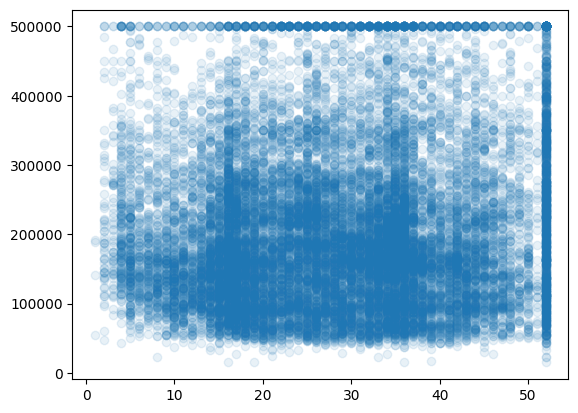

In [13]:
plt.scatter(df.housing_median_age, df.median_house_value, alpha=0.1)

In [14]:
df['housing_median_age_bin']= pd.qcut(df['housing_median_age'], q=5, labels=False) + 1

In [18]:
grouped_age = df.groupby('housing_median_age_bin').mean(numeric_only=True)

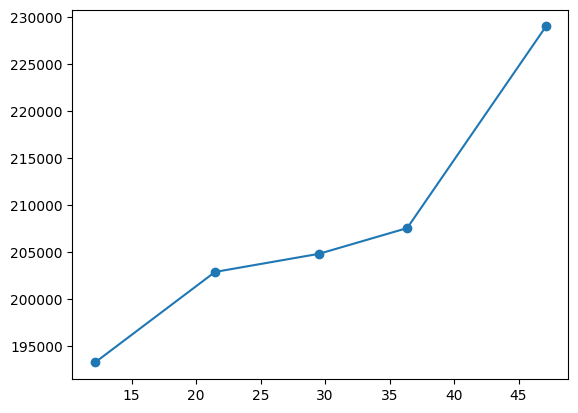

In [19]:
plt.plot(grouped_age.housing_median_age.values, grouped_age.median_house_value.values, marker="o")

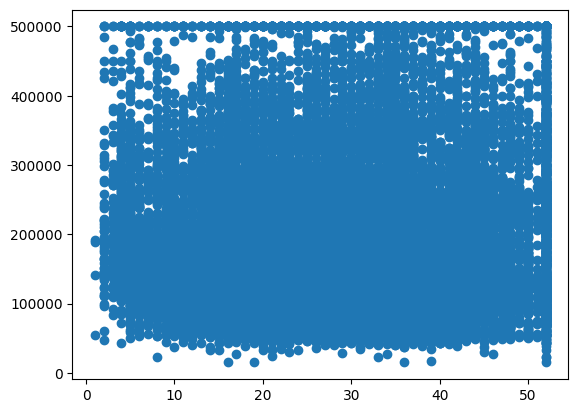

In [44]:
# Grafica edad promedio casa vs precio casa
plt.scatter(df.housing_median_age, df.median_house_value)

In [46]:
# Elimina los máximos de precio casa
df = df[df.housing_median_age != df.median_house_value.max()]

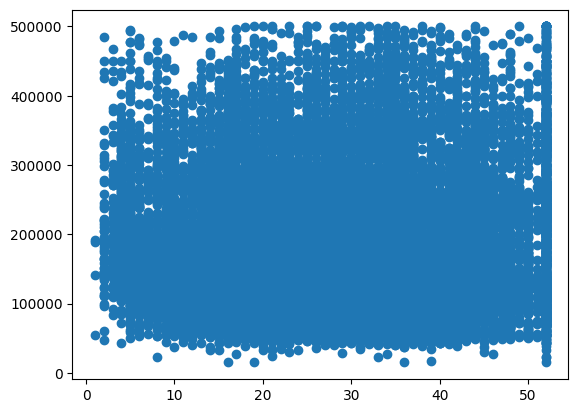

In [47]:
# Grafica sin los máximos
plt.scatter(df.housing_median_age, df.median_house_value)

In [51]:
model1 = linear_model.LinearRegression()
X = df[['housing_median_age']]
y = df[['median_house_value']]

# Fit the model to the data
model1.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model1.intercept_)
print(model1.coef_)

[177411.79806093]
[[530.7537496]]


Ecuación:
$$Precio  = 177411.79 + 530.75* edad media casa $$

In [53]:
# Aplicando el modelo1
177411.79806093 + 530.7537496 * X

,housing_median_age
0,199172.701795
1,188557.626803
2,205010.993040
3,205010.993040
4,205010.993040
...,...
20635,190680.641801
20636,186965.365554
20637,186434.611804
20638,186965.365554


In [55]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones1 = model1.predict(X)
predicciones1

array([[199172.7017945 ],
       [188557.62680252],
       [205010.99304009],
       ...,
       [186434.61180412],
       [186965.36555372],
       [185903.85805452]])

In [56]:
df['predicciones1'] = predicciones1

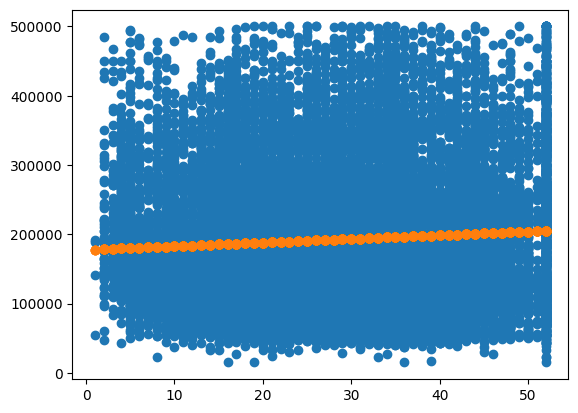

In [57]:
plt.scatter(df.housing_median_age, df.median_house_value)
plt.scatter(df.housing_median_age, df.predicciones1)

In [60]:
np.mean((df.predicciones1 - df.median_house_value)**2)

9502976334.705992

In [61]:
from sklearn.metrics import mean_squared_error

In [62]:
mean_squared_error(y_true = df.median_house_value,
                   y_pred = df.predicciones1)

9502976334.705992

In [124]:
from sklearn.metrics import r2_score as r2

In [125]:
r2(y_true = df.median_house_value,
   y_pred = df.predicciones1)

0.004616870761556036

analisis bivariado total_rooms

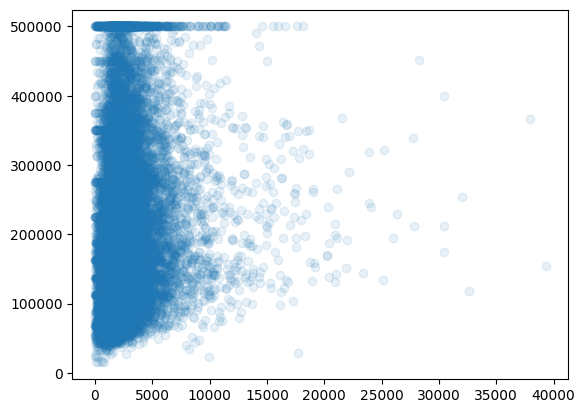

In [20]:
plt.scatter(df.total_rooms, df.median_house_value, alpha=0.1)

In [25]:
df["total_rooms_bin"] = pd.qcut(df.total_rooms, q=10, labels=False) + 1

In [26]:
grouped_rooms = df.groupby('total_rooms_bin').mean(numeric_only=True)

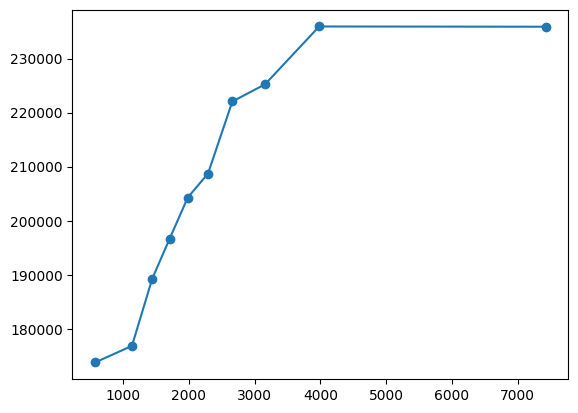

In [27]:
plt.plot(grouped_rooms.total_rooms.values, grouped_rooms.median_house_value.values, marker="o")

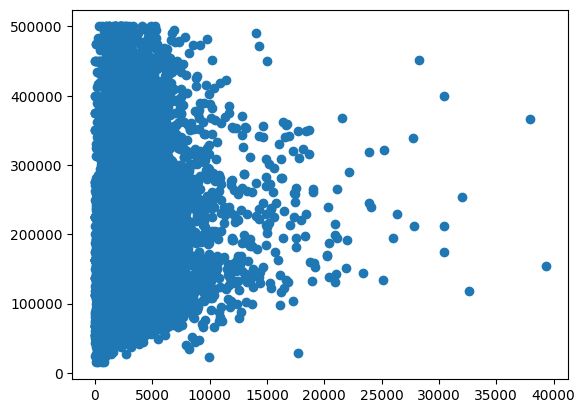

In [74]:
# Grafica cuartos totales vs precio casa
plt.scatter(df.total_rooms, df.median_house_value)

In [64]:
df = df[df.total_rooms != df.median_house_value.max()]

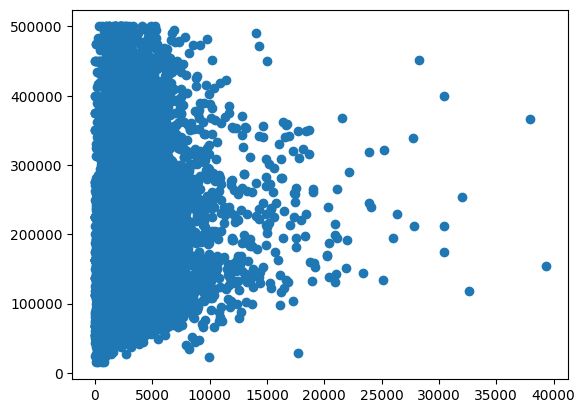

In [65]:
plt.scatter(df.total_rooms, df.median_house_value)

In [66]:
model2 = linear_model.LinearRegression()
X = df[['total_rooms']]
y = df[['median_house_value']]

# Fit the model to the data
model2.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model2.intercept_)
print(model2.coef_)

[175680.60158723]
[[6.411769]]


Ecuación : $$Precio  = 175680.6 + 6.41* cuartos $$

In [67]:
# Aplicando el modelo1
175680.60158723 + 6.411769 * X

,total_rooms
0,181322.958307
1,221197.749718
2,185086.666710
3,183849.195293
4,186112.549750
...,...
20635,186356.196972
20636,180149.604580
20637,190132.728913
20638,187606.491927


In [68]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones2 = model2.predict(X)
predicciones2

array([[181322.95831066],
       [221197.74974585],
       [185086.66671594],
       ...,
       [190132.728922  ],
       [187606.49193447],
       [193537.37826307]])

In [69]:
df['predicciones2'] = predicciones2

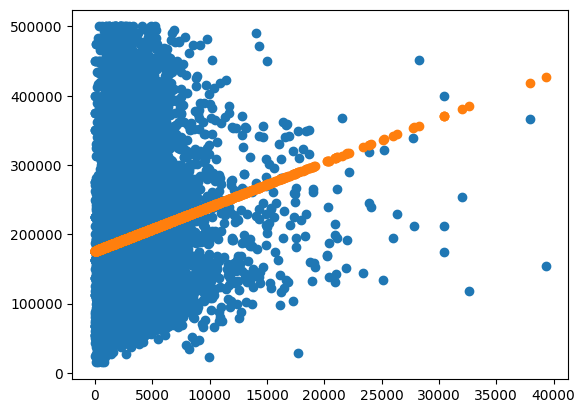

In [70]:
plt.scatter(df.total_rooms, df.median_house_value)
plt.scatter(df.total_rooms, df.predicciones2)

In [71]:
np.mean((df.predicciones2 - df.median_house_value)**2)

9351447180.215874

In [72]:
from sklearn.metrics import mean_squared_error

In [73]:
mean_squared_error(y_true = df.median_house_value,
                   y_pred = df.predicciones2)

9351447180.215874

In [126]:
r2(y_true = df.median_house_value,
   y_pred = df.predicciones2)

0.020488694351853853

analisis bivariado total_bedrooms

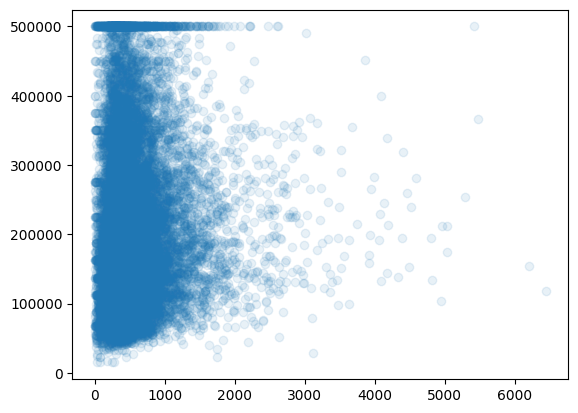

In [30]:
plt.scatter(df.total_bedrooms, df.median_house_value, alpha=0.1)

In [31]:
df['total_bedrooms_bin']= pd.qcut(df['total_bedrooms'], q=10, labels=False) + 1

In [33]:
grouped_bedrooms = df.groupby('total_bedrooms_bin').mean(numeric_only=True)

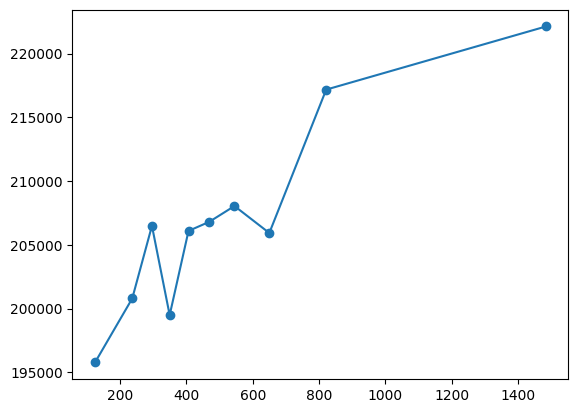

In [34]:
plt.plot(grouped_bedrooms.total_bedrooms.values, grouped_bedrooms.median_house_value.values, marker="o")

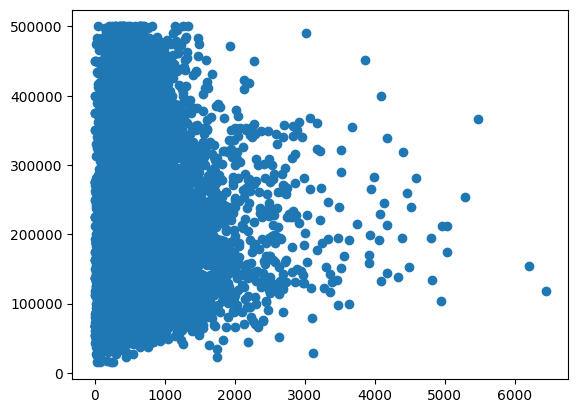

In [75]:
# Grafica cuartos totales vs precio casa
plt.scatter(df.total_bedrooms, df.median_house_value)


In [76]:
df = df[df.total_bedrooms != df.median_house_value.max()]


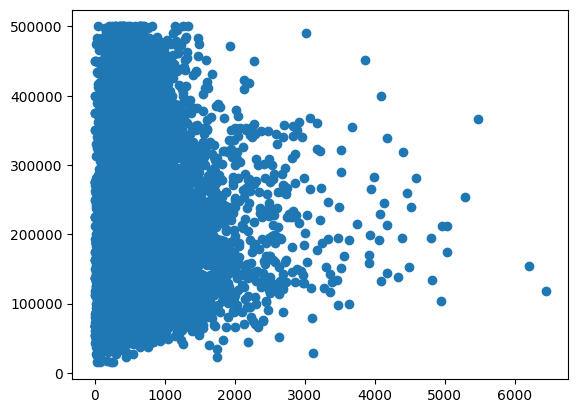

In [77]:
plt.scatter(df.total_bedrooms, df.median_house_value)

In [93]:
model3 = linear_model.LinearRegression()
X = df[['total_bedrooms']].fillna(0)  # Fill NA with 0
y = df[['median_house_value']]

# Fit the model to the data
model3.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model3.intercept_)
print(model3.coef_)

[183455.69921143]
[[16.89048081]]


Ecuación : $$Precio  = 183455.7 + 16.89* habitaciones $$


In [96]:
# Aplicando el modelo3
183455.69921143 + 16.89048081 * X


,total_bedrooms
0,185634.571236
1,202136.570987
2,186664.890565
3,187424.962202
4,188185.033838
...,...
20635,189772.739034
20636,185989.271333
20637,191647.582404
20638,190363.905863


In [97]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones3 = model3.predict(X)
predicciones3


array([[185634.57123597],
       [202136.5709877 ],
       [186664.8905654 ],
       ...,
       [191647.58240446],
       [190363.90586287],
       [193860.23539062]])

In [99]:
df['predicciones3'] = predicciones3


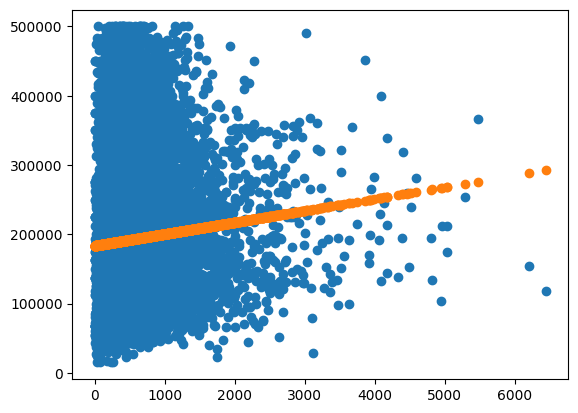

In [100]:
plt.scatter(df.total_bedrooms, df.median_house_value)
plt.scatter(df.total_bedrooms, df.predicciones3)


In [101]:
np.mean((df.predicciones3 - df.median_house_value)**2)



9495833114.733957

In [102]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_true = df.median_house_value,
                   y_pred = df.predicciones3)


9495833114.733957

In [127]:
r2(y_true = df.median_house_value,
   y_pred = df.predicciones3)

0.005365082732013637

analisis bivariado population

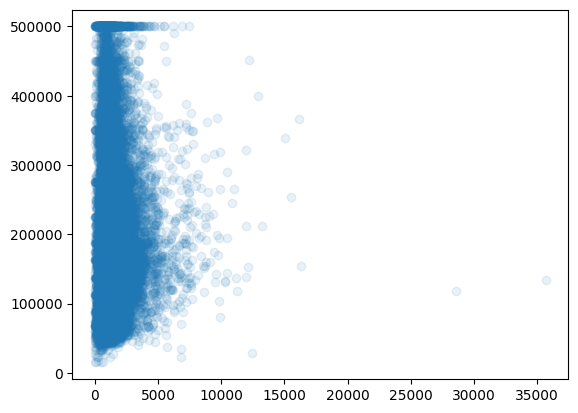

In [35]:
plt.scatter(df.population, df.median_house_value, alpha=0.1)

In [36]:
df['population_bin']= pd.qcut(df['population'], q=10, labels=False) + 1

In [37]:
grouped_population = df.groupby('population_bin').mean(numeric_only=True)

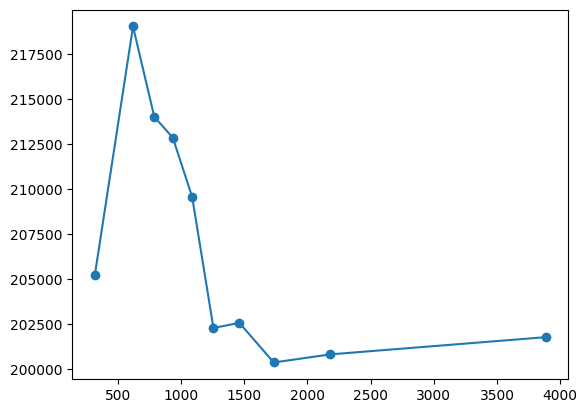

In [38]:
plt.plot(grouped_population.population.values, grouped_population.median_house_value.values, marker="o")

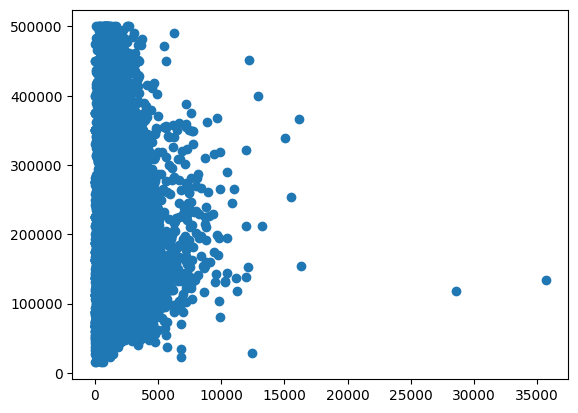

In [103]:
# Grafica población vs precio casa
plt.scatter(df.population, df.median_house_value)

In [104]:
df = df[df.population != df.median_house_value.max()]


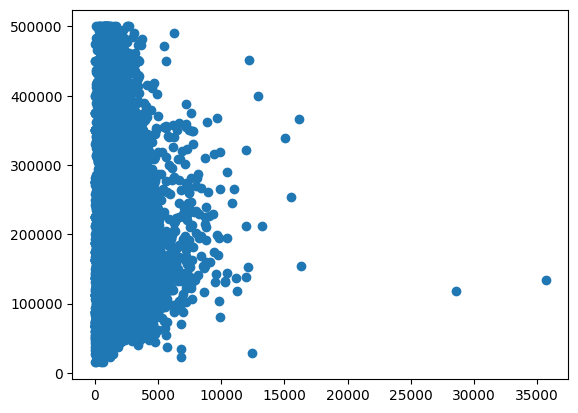

In [105]:
plt.scatter(df.population, df.median_house_value)


In [106]:
model4 = linear_model.LinearRegression()
X = df[['population']]
y = df[['median_house_value']]

# Fit the model to the data
model4.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model4.intercept_)
print(model4.coef_)

[191005.0921059]
[[1.02222129]]


Ecuación : $$Precio  = 191005.1 + 1.02* población $$



In [107]:
# Aplicando el modelo1
191005.0921059 + 1.02222129 * X

,population
0,191334.247361
1,193459.445423
2,191512.113866
3,191575.491586
4,191582.647135
...,...
20635,191868.869096
20636,191369.002885
20637,192034.468945
20638,191762.558082


In [108]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones4 = model4.predict(X)
predicciones4


array([[191334.24736278],
       [193459.44543437],
       [191512.11386805],
       ...,
       [192034.46894962],
       [191762.55808524],
       [192422.91304158]])

In [109]:
df['predicciones4'] = predicciones4

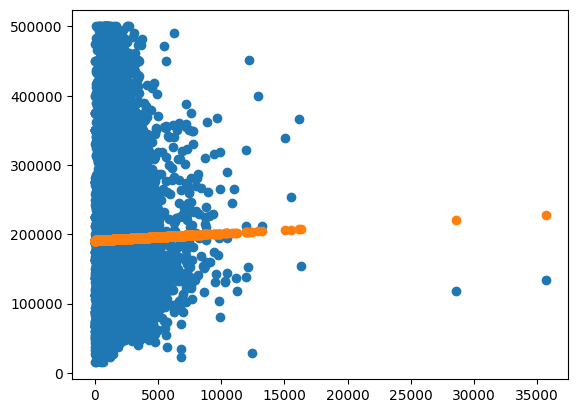

In [110]:
plt.scatter(df.population, df.median_house_value)
plt.scatter(df.population, df.predicciones4)


In [111]:
np.mean((df.predicciones4 - df.median_house_value)**2)


9545687211.793386

In [113]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_true = df.median_house_value,
                   y_pred = df.predicciones4)


9545687211.793386

In [128]:
r2(y_true = df.median_house_value,
   y_pred = df.predicciones4)

0.00014314747840893371

analisis bivariado households

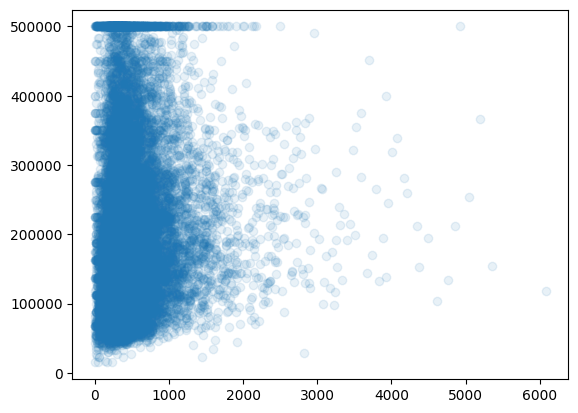

In [39]:
plt.scatter(df.households, df.median_house_value, alpha=0.1)

In [40]:
df['households_bin']= pd.qcut(df['households'], q=10, labels=False) + 1

In [41]:
grouped_households = df.groupby('households_bin').mean(numeric_only=True)

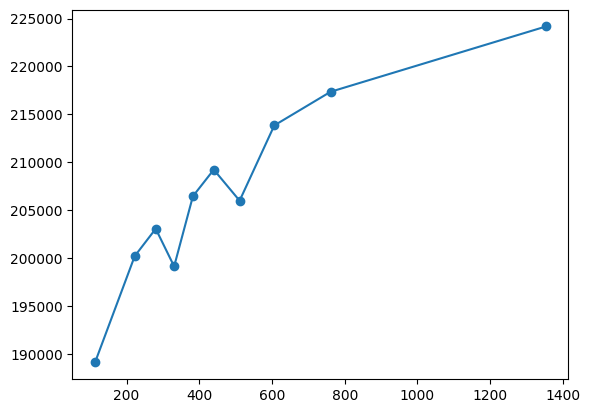

In [42]:
plt.plot(grouped_households.households.values, grouped_households.median_house_value.values, marker="o")

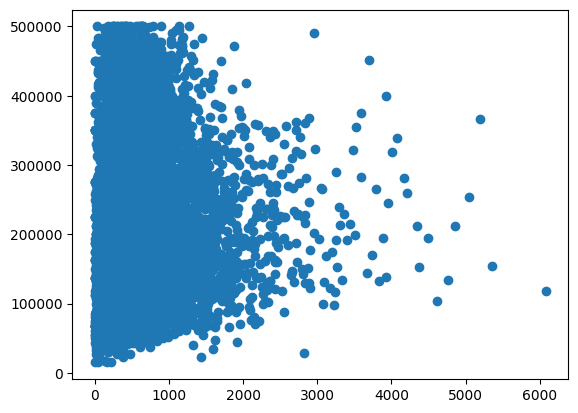

In [114]:
# Grafica viviendas vs precio casa
plt.scatter(df.households, df.median_house_value)



In [115]:
df = df[df.households != df.median_house_value.max()]


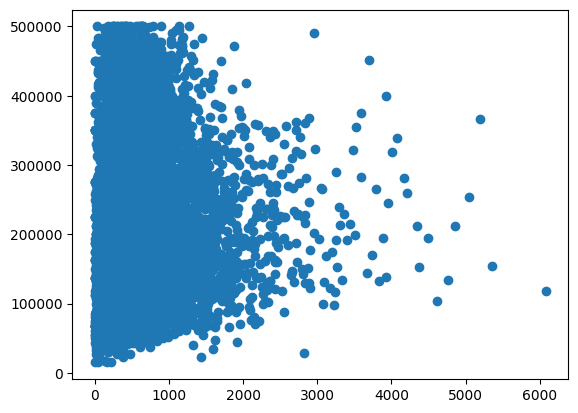

In [116]:
plt.scatter(df.households, df.median_house_value)


In [117]:
model5 = linear_model.LinearRegression()
X = df[['households']]
y = df[['median_house_value']]

# Fit the model to the data
model5.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model5.intercept_)
print(model5.coef_)


[180352.83033456]
[[24.19279495]]


Ecuación : $$Precio  = 180352.8 + 24.19* cuartos $$



In [118]:
# Aplicando el modelo1
180352.83033456 + 24.19279495 * X

,households
0,183401.122498
1,207884.230988
2,184634.955041
3,185651.052429
4,186618.764227
...,...
20635,188336.452668
20636,183110.808959
20637,190828.310548
20638,188796.115772


In [119]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones5 = model5.predict(X)
predicciones5


array([[183401.12249796],
       [207884.23098498],
       [184634.95504029],
       ...,
       [190828.31054689],
       [188796.11577129],
       [193175.01165681]])

In [120]:
df['predicciones5'] = predicciones5



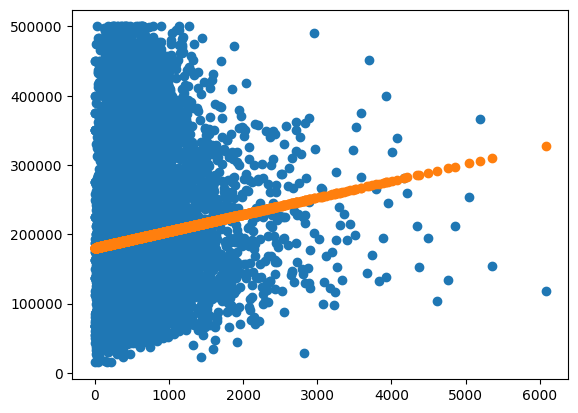

In [121]:
plt.scatter(df.households, df.median_house_value)
plt.scatter(df.households, df.predicciones5)



In [122]:
np.mean((df.predicciones5 - df.median_house_value)**2)



9461083732.794487

In [123]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_true = df.median_house_value,
                   y_pred = df.predicciones5)


9461083732.794487

In [129]:
r2(y_true = df.median_house_value,
   y_pred = df.predicciones5)

0.009004884338978392

RESPUESTA:
¿Cuál es el mejor modelo de estos? ¿Por qué?

Analisando los resultados podemos decir que el mejor modelo es el que utiliza la variable de total_rooms ya que su R^2 es la mayor (0.02). Tomamos este parámetro ya que el R^2 indica que tan bien una regresión lineal se ajusta a los datos. Sin embargo, sigue siendo muy bajo R^2. Con utilizar solo esta variable no sería suficente para poder tener un optimo modelo para la predicción de precios.